# 🧹 Data Cleaning, Feature Engineering & Validation
In this notebook, we will:
1. Clean the data (handle missing IDs, drop cancellations for RFM).
2. Engineer RFM (Recency, Frequency, Monetary) features.
3. Calculate rolling statistics.
4. Validate our engineered features using `great_expectations`.

In [ ]:
# Loading Libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import great_expectations as gx

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

## 1. Load the Data
We'll load the merged dataset checkpoint we created at the end of the EDA.

In [2]:
try:
    df = pd.read_csv('../data/processed/online_retail_initial.csv', parse_dates=['InvoiceDate'])
    print(f"Successfully loaded {len(df)} rows.")
except FileNotFoundError:
    print("Error: Could not find the processed CSV. Please make sure you ran the save checkpoint cell in the EDA notebook.")

Successfully loaded 1033035 rows.


## 2. Data Cleaning
For RFM analysis, we need a valid `CustomerID`. We also want to separate standard purchases from returns/cancellations.

In [3]:
clean_df = df.dropna(subset=['CustomerID']).copy()

# Separate purchases from cancellations (Quantity > 0)
purchases = clean_df[clean_df['Quantity'] > 0].copy()
print(f"Rows after dropping missing IDs and cancellations: {len(purchases)}")

Rows after dropping missing IDs and cancellations: 779494


## 3. Feature Engineering: RFM Scores
**📊 RFM** stands for **Recency**, **Frequency**, and **Monetary** value.  
It’s a behavior-based customer segmentation method used to rank customers based on:

- 🕒 **Recency**: How recently did the customer purchase? (Days since last purchase)
- 🔁 **Frequency**: How often do they purchase? (Number of unique invoices) 
- 💰 **Monetary**: How much do they spend? (Total sum of purchases)

**We can identify best customers (high R, F, M) vs. at-risk or loyal but low-spending ones. Common in marketing for targeting, retention, and rewards 🎁**

In [4]:
# A snapshot date (usually the day after the last transaction in the dataset)
snapshot_date = purchases['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM metrics
rfm = purchases.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalPrice': 'sum'                                      # Monetary
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

# ---- Drop £0 spenders (free items) ----
rfm = rfm[rfm['Monetary'] > 0]
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


## 4. Feature Engineering: Rolling Statistics 📦
We can calculate rolling statistics, such as the 7-day rolling average of daily total revenue, which helps smooth out day-to-day volatility and highlights longer-term trends.

- 🕐 Short window (7d) → captures recent changes

- 📅 Long window (30d) → captures seasonal/base demand

In [5]:
# Group by Date to get daily total sales
daily_sales = purchases.groupby(purchases['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
daily_sales['InvoiceDate'] = pd.to_datetime(daily_sales['InvoiceDate'])

**📌 We take 7 consecutive days, add them up, divide by 7**

In [6]:
daily_sales['Rolling_7D_Avg'] = daily_sales['TotalPrice'].rolling(window=7).mean()

**📌 We take 30 consecutive days, add them up, divide by 30**

In [7]:
daily_sales['Rolling_30D_Avg'] = daily_sales['TotalPrice'].rolling(window=30).mean()

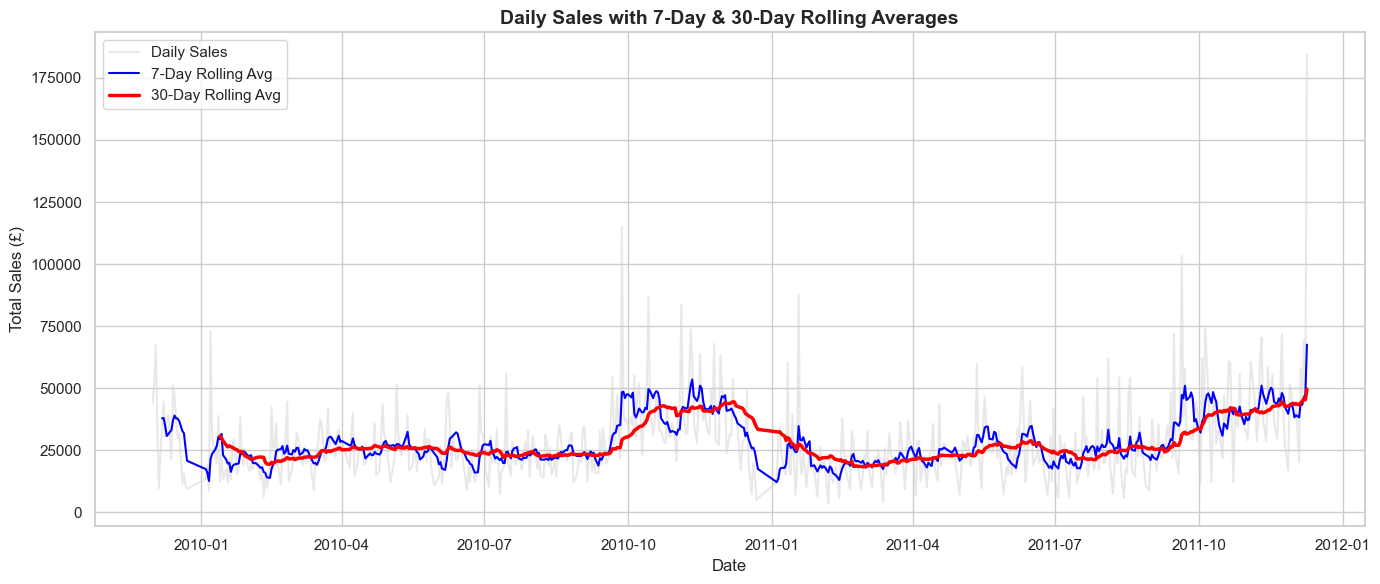

In [8]:
# Plot the rolling statistics
plt.figure(figsize=(14, 6))
sns.lineplot(data=daily_sales, x='InvoiceDate', y='TotalPrice', color='lightgrey', label='Daily Sales', alpha=0.5)
sns.lineplot(data=daily_sales, x='InvoiceDate', y='Rolling_7D_Avg', color='blue', label='7-Day Rolling Avg', linewidth=1.5)
sns.lineplot(data=daily_sales, x='InvoiceDate', y='Rolling_30D_Avg', color='red', label='30-Day Rolling Avg', linewidth=2.5)

plt.title('Daily Sales with 7-Day & 30-Day Rolling Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Total Sales (£)')
plt.legend()
plt.tight_layout()
plt.show()

## 5. Data Validation with Great Expectations
Before we use our RFM features for modeling, we need to validate them. `great_expectations` allows us to define strict rules (expectations) about what our data should look like.

In [9]:
# --- Quick sanity check ---
print("🔍 Missing Values per DataFrame:\n")
print("=" * 40)

print("\n📦 df (transactions):")
print(df.isnull().sum())

print("\n📊 rfm (customer scores):")
print(rfm.isnull().sum())

print("\n📈 daily_sales (features):")
print(daily_sales.isnull().sum())

🔍 Missing Values per DataFrame:


📦 df (transactions):
InvoiceNo           0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     235151
Country             0
TotalPrice          0
Year                0
Month               0
Day                 0
Hour                0
YearMonth           0
dtype: int64

📊 rfm (customer scores):
CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

📈 daily_sales (features):
InvoiceDate         0
TotalPrice          0
Rolling_7D_Avg      6
Rolling_30D_Avg    29
dtype: int64


In [10]:
context = gx.get_context()
data_source = context.data_sources.add_pandas("rfm_data")
data_asset = data_source.add_dataframe_asset(name="rfm_asset")
batch_definition = data_asset.add_batch_definition_whole_dataframe("rfm_batch")
batch = batch_definition.get_batch(batch_parameters={"dataframe": rfm})
suite = gx.ExpectationSuite(name="rfm_validation_suite")
context.suites.add(suite)
validator = context.get_validator(batch=batch, expectation_suite_name="rfm_validation_suite")

print("1. Expect 'CustomerID' to be unique & not null:")
res1 = validator.expect_column_values_to_be_unique("CustomerID")
res2 = validator.expect_column_values_to_not_be_null("CustomerID")
print("Unique Success:", res1['success'])
print("Not Null Success:", res2['success'], "\n")

print("2. Expect 'Recency' to be >= 1:")
res3 = validator.expect_column_values_to_be_between("Recency", min_value=1, max_value=None)
print("Success:", res3['success'], "\n")

print("3. Expect 'Frequency' to be >= 1:")
res4 = validator.expect_column_values_to_be_between("Frequency", min_value=1, max_value=None)
print("Success:", res4['success'], "\n")

print("4. Expect 'Monetary' to be > 0:")
res5 = validator.expect_column_values_to_be_between("Monetary", min_value=0.001, max_value=None)
print("Success:", res5['success'])

1. Expect 'CustomerID' to be unique & not null:


Calculating Metrics: 100%|██████████| 6/6 [00:00<00:00, 275.42it/s]


Unique Success: True
Not Null Success: True 

2. Expect 'Recency' to be >= 1:


Calculating Metrics: 100%|██████████| 8/8 [00:00<00:00, 272.60it/s]


Success: True 

3. Expect 'Frequency' to be >= 1:


Calculating Metrics: 100%|██████████| 8/8 [00:00<00:00, 305.24it/s]


Success: True 

4. Expect 'Monetary' to be > 0:


Calculating Metrics: 100%|██████████| 8/8 [00:00<00:00, 354.96it/s]

Success: True


| Check | Result | Meaning |
|-------|--------|---------|
| `'Customer ID not null'` | `np.True_` | ✅ Every transaction has a customer ID |
| `'Quantity >= 0'` | `np.True_` | ✅ No negative quantities (no returns counted as sales) |
| `'Price >= 0'` | `np.True_` | ✅ No negative prices |

> **All 3 checks passed → Data is clean and ready for analysis**

### Save Validated Features
Since our features passed validation, we can safely save them for the next phase (Clustering & Modeling).

In [11]:
rfm.to_csv('../data/processed/rfm_features.csv', index=False)
print("RFM features saved to ../data/processed/rfm_features.csv")

RFM features saved to ../data/processed/rfm_features.csv
